In [2]:
from physics.hstar import gghzz, c6
from physics.hzz import angles, zpair
from physics.simulation import msq

import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
sample = gghzz.Process(msq.Component.SBI, (1.5569109, '/raven/u/taepa/mcfm/MCFM-10.3/Bin/ggZZ2e2m_sbi/events.csv', 1e5))

In [20]:
c6mod = c6.Modifier(sample, baseline = msq.Component.SIG, c6_values = [-5,-1,0,1,5])
coefficients = c6mod.coefficients

In [102]:
random_event_index = 10000
random_event_coeffs = coefficients[random_event_index,:]
random_event_kinematics = sample.events.kinematics.iloc[random_event_index]
random_event_weight = sample.events.weights.iloc[random_event_index]

def kinematical_distance(kinematics, event):
  return np.sqrt(
    np.square(kinematics['p3_px'] - event['p3_px']) + 
    np.square(kinematics['p4_px'] - event['p4_px']) + 
    np.square(kinematics['p5_px'] - event['p5_px']) + 
    np.square(kinematics['p6_px'] - event['p6_px']))

def m4l(kinematics):
  return np.sqrt(
    np.square(kinematics['p3_E']+kinematics['p4_E']+kinematics['p5_E']+kinematics['p6_E'])-
    np.square(kinematics['p3_px']+kinematics['p4_px']+kinematics['p5_px']+kinematics['p6_px'])-
    np.square(kinematics['p3_py']+kinematics['p4_py']+kinematics['p5_py']+kinematics['p6_py'])-
    np.square(kinematics['p3_pz']+kinematics['p4_pz']+kinematics['p5_pz']+kinematics['p6_pz'])
                 )

def m4l_distance(kinematics, event):
  return m4l(kinematics) - m4l(events)

kinematical_distance_to_random_event = kinematical_distance(sample.events.kinematics, random_event_kinematics)
m4l_distance_to_random_event = m4l_distance(sample.events.kinematics, random_event_kinematics)

print(kinematical_distance_to_random_event.shape)

(100000,)


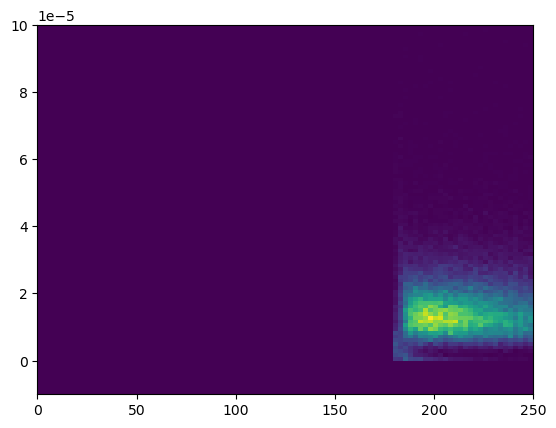

In [105]:
counts = plt.hist2d(m4l(sample.events.kinematics), sample.events.weights, bins=[np.linspace(0,250,100),np.linspace(-0.00001,0.0001,100)])

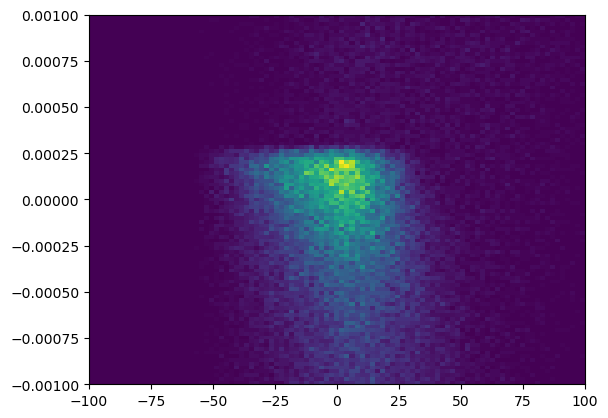

In [82]:
counts = plt.hist2d(m4l_distance_to_random_event, coefficients[:,1] - random_event_coeffs[1], bins=[np.linspace(-100,100,100),np.linspace(-0.001,0.001,100)])
counts = plt.hist2d(m4l_distance_to_random_event, coefficients[:,2] - random_event_coeffs[2], bins=[np.linspace(-100,100,100),np.linspace(-0.001,0.001,100)])

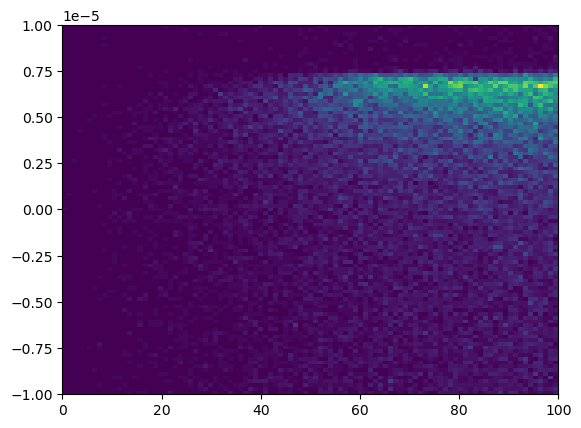

In [66]:
counts = plt.hist2d(kinematical_distance_to_random_event, coefficients[:,1] - random_event_coeffs[1], bins=[np.linspace(0,100,100),np.linspace(-0.01,0.01,100)])
counts = plt.hist2d(kinematical_distance_to_random_event, coefficients[:,3] - random_event_coeffs[3], bins=[np.linspace(0,100,100),np.linspace(-1e-5,1e-5,100)])